# ĐỒ ÁN THỰC HÀNH #2

## Giai đoạn 1: Data Cleaning & Data Preprocessing

## Môn học: Phân tích dữ liệu ứng dụng - CSC12110

Các thành viên và bảng đánh giá:

| STT | MSSV     | Họ tên           | Công việc đã thực hiện trong giai đoạn 1 | Tỉ lệ công việc (trên tổng số 100%) | Đánh giá (thang 100%) | Ghi chú |
| --- | ----     | ---------------- | ---------------------- | --------------- | --------------------- | ------- |
| 1   | 22127012 | Nguyễn Hà Anh    | Thực hiện tiền xử lí phần 1.4 | 25% | 100% |  |
| 2   | 22127205 | Bùi Lê Khôi      | Thực hiện tiền xử lí phần 1.1, 1.2 | 25% | 100% | Leader |
| 3   | 22127260 | Bùi Công Mậu     | Thực hiện tiền xử lí phần 1.3 | 25% | 100% |  |
| 4   | 22127400 | Thái Hữu Thọ     | Thực hiện tiền xử lí phần 1.2 | 25% | 100% |  |

---

Link sản phẩm:

- Drive: [DA_05_S1_2526](https://drive.google.com/drive/u/0/folders/1TPJKcKhVyfVeW6RG4pF22pNRB-k1RA9r)
  - Giai đoạn 1 - Data Cleaning & Data Preprocessing: [DA_05_GD1_Preprocessing](https://colab.research.google.com/drive/12gd8Hqaj5c117MPsPFZiHgXDFbH3MjDn)
  - Giai đoạn 2 - EDA: [DA_05_GD2_EDA](https://colab.research.google.com/drive/1nnAVOIJJaglbqq1lOBo9OiKlEMXFFqnO)
  - Giai đoạn 3 - Hypothesis Testing: [DA_05_GD3_Hypothesis_Testing](https://colab.research.google.com/drive/1gVtnBd4bN6eDq8xDgmxVu3IEwPYaTBsa)
  - Giai đoạn 4 - DA_05_GD4_Model_Evaluation + Bonus Tasks: [DA_05_GD4_Model_Evaluation+Bonus](https://colab.research.google.com/drive/1DE0dN8WIMKHM_72EjdzM_iXx8nAXOCLM)

- Video Demo: [Final_DA_05](https://drive.google.com/file/d/1cvEYJuuxS5Zg5s358HRbRD8DQqvk3WBg/view)

---

### Cập nhật 05/01/2025:

- Thêm mô tả các hướng xử lí missing data (phần 1.2.2)
- Thêm mô tả lý do chọn tham số y khoa và reference (phần 1.3).

---
---

## Mô tả đồ án

- Mục tiêu: **Dự đoán khả năng một người có mắc bệnh tim hay không**.

    - Biến mục tiêu: ```target``` (1 = bệnh, 0 = không bệnh).

- Dataset: [Heart Disease UCI Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

---

### Import các libs và dependencies

In [ ]:
import re
import os
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl
import seaborn as sns
import statsmodels.api as sm
import datetime as dt

from datetime import timedelta
from scipy import stats
from math import sqrt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, pairwise_distances, silhouette_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from google.colab import drive
import warnings
warnings.filterwarnings("ignore")

# Ensure plots appear in the notebook
%matplotlib inline

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

Last updated: Wed Dec 31 16:48:47 2025


In [ ]:
# authorization
drive.mount('/content/drive')

# Check if the directory exists and list files
folder_path = '/content/drive/MyDrive/DA_05_S1_2526'

if os.path.exists(folder_path):
    print("Folder found. Files inside:")
    print(os.listdir(folder_path))
else:
    print(f"Folder not found at: {folder_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder found. Files inside:
['PTDLUD_HK1_2526_DATH_nopass.pdf', 'Ôn thi cuối kì.gdoc', 'heart_disease_uci.csv', 'DA_05_GD4_Model_Evaluation+Bonus.ipynb', 'DA_05_GD3_Hypothesis_Testing.ipynb', 'DA_05_GD2_EDA.ipynb', 'DA_05_GD1_Preprocessing.ipynb']


---
---

#  Giai đoạn 1: Data Cleaning & Data Preprocessing

## 1.1. Đọc và nhận xét dữ liệu từ file csv

### 1.1.1. Đọc dữ liệu

In [ ]:
# Read csv file
df = pd.read_csv('/content/drive/MyDrive/DA_05_S1_2526/heart_disease_uci.csv')
# Check the data
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


Dữ liệu có 920 dòng và 16 cột thuộc tính.

---

### 1.1.2. Kiểm tra kiểu của các cột dữ liệu

In [ ]:
print("Thông tin tổng quan về DataFrame:", df.info())
# In ra xem ID có unique không
if df['id'].is_unique:
    print("Cột 'id' có các giá trị duy nhất.")
else:
    print("Cột 'id' không có các giá trị duy nhất.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalach   865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
Thông tin tổng quan về DataFrame: None
Cột 'id' có các giá trị duy nhất.


---

### 1.1.3. Thống kê cơ bản

#### Xem phân loại các cột định lượng và định tính dựa theo thuộc tính cột


In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

Numeric cols: ['id', 'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'num']
Categorical cols: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


#### Thống kê cơ bản của dữ liệu định lượng

In [ ]:
df.describe()

,id,age,trestbps,chol,thalach,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


---

### 1.1.4. Kiểm tra null và các dữ liệu không hợp lí/bất thường

#### Kiểm tra null

In [ ]:
# Xem xét các giá trị null trong DataFrame, sort theo Null percent
pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Null count': df.isnull().sum().values,
    'Null percent (%)': df.isnull().sum().values / len(df) * 100,
    'Unique count': df.nunique().values
}).sort_values(by='Null percent (%)', ascending=False)

,Column,Dtype,Null count,Null percent (%),Unique count
13,ca,float64,611,66.413043,4
14,thal,object,486,52.826087,3
12,slope,object,309,33.586957,3
7,fbs,object,90,9.782609,2
11,oldpeak,float64,62,6.739130,53
5,trestbps,float64,59,6.413043,61
10,exang,object,55,5.978261,2
9,thalach,float64,55,5.978261,119
6,chol,float64,30,3.260870,217
8,restecg,object,2,0.217391,3


---

### 1.1.5. Nhận xét về Dữ liệu

- Dữ liệu có 920 dòng và 16 cột.

- Các **đặc trưng đầu vào** trong dataset trên gồm:
    - ```id```: Mã số duy nhất cho mỗi bệnh nhân.
    - ```age```: Tuổi của bệnh nhân.
    - ```sex```: Giới tính (Male - Nam/Female - Nữ)
    - ```dataset```: Nơi nghiên cứu.
    - ```cp```: Loại đau thắt ngực. Giá trị gồm:
        - ```typical angina```: đau thắt ngực điển hình
        - ```atypical angina```: đau thắt ngực không điển hình
        - ```non-anginal```: không đau thắt ngực
        - ```asymptomatic```: không triệu chứng
    - ```trestbps```: Huyết áp lúc nghỉ (tính bằng mmHg khi nhập viện).
    - ```chol```: Nồng độ cholesterol huyết thanh tính bằng mg/dl.
    - ```fbs```: Trả về TRUE nếu đường huyết lúc đói > 120 mg/dl, ngược lại trả về FALSE.
    - ```restecg```: Kết quả điện tâm đồ lúc nghỉ: Giá trị gồm:
        - ```normal```: bình thường
        - ```stt abnormality```: bất thường ST-T.
        - ```lv hypertrophy```: phì đại thất trái.
    - ```thalach```: nhịp tim tối đa đạt được
    - ```exang```: Trả về TRUE nếu có đau thắt ngực do gắng sức, ngược lại trả về FALSE.
    - ```oldpeak```: ST chênh xuống do gắng sức so với lúc nghỉ.
    - ```slope```: độ dốc của đỉnh đoạn ST khi gắng sức. Giá trị gồm:
        - ```upsloping```: Đi lên. Bình thường nếu giá trị dương nhỏ, bất thường nếu dương lớn.
        - ```flat```: Nằm ngang. Thường sẽ đc chẩn đoán là thiếu máu cục bộ cơ tim.
        - ```downsloping```: Đi xuống. Là dấu hiệu cảnh báo tình trạng thiếu máu cơ tim nghiêm trọng hoặc tổn thương cơ tim.
    - ```ca```: số mạch máu chính được tô màu bằng huỳnh quang. Giá trị nằm trong tập {0, 1, 2, 3}.
    - ```thal```: Giá trị gồm:
        - ```normal```: bình thường
        - ```fixed defect```: khuyết cố định
        - ```reversable defect```: khuyết có thể hồi phục
    - ```num```: thuộc tính dự đoán, chỉ ra tính chất bệnh tim của bệnh nhân. Giá trị gồm:
        - ```0```: Không có dấu hiệu bệnh tim.
        - ```1```: Có bệnh tim mức độ nhẹ.
        - ```2```: Có bệnh tim ở mức độ trung bình.
        - ```3```: Có bệnh tim ở mức độ nặng.
        - ```4```: Có bệnh tim ở mức độ rất nặng.

- **Phân loại đặc trưng**:
    - Các đặc trưng định lượng (Quantitative):
        - Định lượng liên tục (Continuous): ```trestbps```, ```chol```, ```thalach```, ```oldpeak```, ```age```.
        - Định lượng rời rạc (Discrete): ```ca```.
    - Các đặc trưng định tính (Qualitative):
        - Định tính danh nghĩa (Nominal): ```id```, ```sex```, ```dataset```, ```cp```, ```restecg```, ```slope```, ```thal```.
        - Định tính thứ tự (Ordinal): ```fbs```, ```exang```, ```num```.

- **Nhận xét**:

    - Ngoại trừ các cột đặc trưng để phân biệt mỗi dòng (```id```, ```age```, ```sex```, ```dataset```, ```num```, ...) và cột ```cp```, các cột còn lại đều có nhiều giá trị missing (null). Điều này có nghĩa là ta phải thực hiện tiền xử lí để điền khuyết cho các cột này.
    - Các biến đều có kiểu dữ liệu như mong muốn (int, float, object). Việc này có lợi là dễ dàng chuyển đổi và mã hóa các biến phân loại khi cần.
    - Các biến phân loại sẽ cần chuyển từ object sang int để dễ mô hình hóa ở các bước sau.
    - Trừ cột ```id``` là unique và một số cột không có nhiều ảnh hưởng, ta cần kiểm tra các cột còn lại để loại bỏ một số giá trị có thể không hợp lệ:

        - ```age```: Tuổi không thể âm, cũng không thể cao bất thường hẳn 200 được. Ta có thể ước lượng 0 < ```age``` < 120
        - ```trestbps``` >= 0 (huyết áp người có thể bằng 0 (như chết lâm sàng, ngưng tim, ...), không thể nhỏ hơn 0), cũng không thể quá thấp hoặc quá cao.
        - ```chol``` > 0, vì máu người không thể có mức cholesterol = 0.
        - ```thalch``` > 0, nhịp tim lúc đập nhanh nhất.
        - ```oldpeak``` có thể bằng 0, dương, hoặc âm, nhưng không quá lớn.

---
---

## 1.2. Xử lí missing value

### 1.2.1. Xem phân bố dữ liệu

Trước hết ta xem phân bố dữ liệu (với các cột dữ liệu định lượng) và thống kê số lượng của mỗi loại (với các cột dữ liệu định tính) để đề ra chiến thuật xử lí.

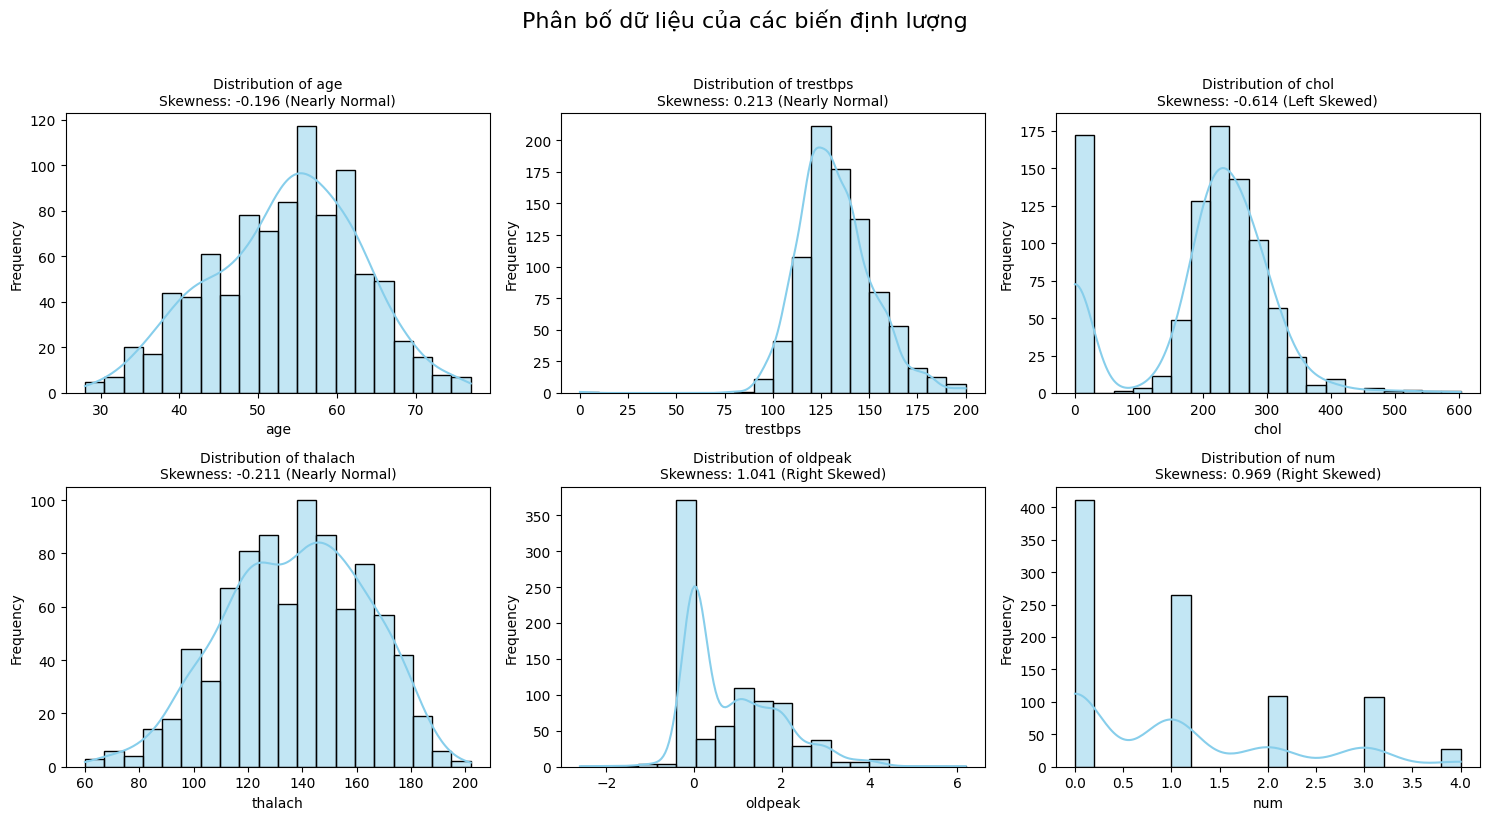

Thống kê tần suất các biến phân loại:
--------------------------------------------------

Cột: fbs
  Giá trị  Số lượng  Tỷ lệ (%)
0   False       692      75.22
1    True       138      15.00
2     NaN        90       9.78
--------------------------------------------------

Cột: restecg
            Giá trị  Số lượng  Tỷ lệ (%)
0            normal       551      59.89
1    lv hypertrophy       188      20.43
2  st-t abnormality       179      19.46
3               NaN         2       0.22
--------------------------------------------------

Cột: exang
  Giá trị  Số lượng  Tỷ lệ (%)
0   False       528      57.39
1    True       337      36.63
2     NaN        55       5.98
--------------------------------------------------

Cột: slope
       Giá trị  Số lượng  Tỷ lệ (%)
0         flat       345      37.50
1          NaN       309      33.59
2    upsloping       203      22.07
3  downsloping        63       6.85
--------------------------------------------------

Cột: thal
             Gi

In [ ]:
# Xem phân phối dữ liệu của các biến số bằng biểu đồ Histogram kèm KDE
# --------------------------------------------------------------------

df_plot = df.copy()

# Lấy danh sách các cột số
numeric_cols = df_plot.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Bỏ qua cột id không có ý nghĩa phân phối, cột age, ca là biến đếm rời rạc
numeric_cols.remove('id')
numeric_cols.remove('ca')

# Vẽ biểu đồ Histogram cho từng biến định lượng còn lại (vẫn vẽ age để tham khảo))
num_plots = len(numeric_cols)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(15, 4 * num_rows))
plt.suptitle('Phân bố dữ liệu của các biến định lượng', fontsize=16, y=1.02)

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    skewness = df[col].skew()
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue', edgecolor='black')
    # Xác định loại phân phối dựa trên skewness
    if abs(skewness) < 0.5:
        skew_label = 'Nearly Normal'
    elif skewness >= 0.5:
        skew_label = 'Right Skewed'
    elif skewness <= -0.5:
        skew_label = 'Left Skewed'
    plt.title(f'Distribution of {col}\nSkewness: {skewness:.3f} ({skew_label})', fontsize=10)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Thống kê tần suất các biến phân loại
# ---------------------------------------------
print("Thống kê tần suất các biến phân loại:")
print("-" * 50)

# Lấy danh sách các cột object
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Thêm các biến đếm rời rạc
object_cols.append('ca')

# Bỏ qua cột sex, cp, dataset do không có missing
object_cols.remove('sex')
object_cols.remove('cp')
object_cols.remove('dataset')

# Lập bảng tần suất cho từng biến phân loại
for col in object_cols:
    print(f"\nCột: {col}")
    count_table = df[col].value_counts(dropna=False).reset_index()
    count_table.columns = ['Giá trị', 'Số lượng']
    count_table['Tỷ lệ (%)'] = (count_table['Số lượng'] / len(df) * 100).round(2)
    print(count_table)
    print("-" * 50)

---

### 1.2.2. Chiến thuật xử lí Missing Value

Để xử lí missing value, các hướng xử lý bao gồm:

- Deletion (xóa): Xóa cột/hàng nếu thiếu quá nhiều và không điền lại được / không quan trọng.
- Imputation (điền khuyết):
  - Điền bằng mean khi data có phân phối chuẩn (không bị lệch nhiều bởi outlier) (data số)
  - Điền bằng median khi data có nhiều outlier, lệch, nhiễu (data số)
  - Điền bằng mode khi data là categorical.
- Interpolation (nội suy): Áp dụng cho dữ liệu kiểu Time Series (chuỗi thời gian)
- Ignorance (bỏ qua): Khi dữ liệu không ảnh hưởng đến những phần còn lại.

Đối với dataset đang có, ngoài việc điền khuyết theo mean/mode/median, ta còn có thể điền khuyết cho dòng chưa biết dựa trên dữ liệu đã biết. Quy trình điền khuyết bằng phương pháp này bao gồm các bước theo thứ tự:

- Tìm trong dataset các dòng dữ liệu có các thuộc tính còn lại gần với giá trị của dòng có thuộc tính missing nhất.
- Lấy các dòng tìm được mà thuộc tính cần điền có giá trị có nghĩa.
- Lấy mean hoặc median cho các giá trị này và điền vào missing value của dòng bị thiếu.

---


Trong 16 cột trên, các cột có 0% null là ```id```, ```age```, ```sex```, ```cp```, ```num```, ```dataset```, ta sẽ không cần điền dữ liệu vào.
Để không bị nhầm lẫn ở các bước sau, ta sẽ đổi tên cột ```dataset``` thành ```location```.

Đối với các cột còn lại:

- Dùng Mode Imputation với các cột ```restecg```, ```fbs```, ```exang```, ```slope```, ```ca```, ```thal```. Đặc điểm chung là chúng đều là dữ liệu định tính - Qualitative (riêng ```ca``` là định lượng rời rạc - Discrete), mỗi cột này chỉ có 1 số hữu hạn và nhỏ giá trị khác nhau. Do đó ta dùng mode của dữ liệu để điền cho các dòng missing.
- Dùng Median Imputation với cột ```oldpeak``` và ```chol```:
    - Đối với ```oldpeak```: Cột này dữ liệu bị lệch phải nặng, giá trị ```skewness``` = 1.041 là lớn, không thể dùng ```mean``` của dữ liệu để điền được, do đó ta dùng Median.
    - Đối với ```chol```:
        - Ta thấy ```skewness``` = -0.614. Về lý thuyết thì dữ liệu lệch trái và nên dùng ```median```.
        - Tuy nhiên, quan sát kĩ ta thấy dữ liệu có một lượng lớn giá trị ```0```, tần suất cao hơn hẳn bất kì giá trị nào khác của thuộc tính (khoảng 175 giá trị trên tổng 920 dòng). Nếu trực tiếp dùng ```median``` để điền cho các giá trị missing, có khả năng giá trị median này sẽ bị lệch. Do đó ta sẽ chuyển các giá trị 0 này về NaN, sau đó lấy ```median``` hoặc ```mean``` của lượng dữ liệu còn lại, và lấy giá trị này điền ngược vào những giá trị NaN của cột.
        - Phần dữ liệu sau khi bỏ các giá trị ```0``` đi có phân phối gần với phân phối chuẩn, nên về mặt lí thuyết dùng ```median``` hay ```mode``` đều được. Trong trường này ta dùng ```median```.

- Dùng Mean Imputation với các cột ```thalach``` và ```trestbps```. Các cột này dữ liệu có phân phối gần với phân phối chuẩn, giá trị skewness nhỏ (```skewness``` = -0.211 với ```thalach``` và ```skewness``` = 0.213 với ```trestbps```), nên có thể dùng ```mean``` của dữ liệu để điền vào các missing value.

> Ví dụ về việc quá nhiều outlier làm median bị lệch: Cho tập X = [11, 13, 15, 17, 19, 21], ta có median = 16; thêm 4 giá trị 0 vào: X = [0, 0, 0, 0, 11, 13, 15, 17, 19, 21], median = 12, lệch đáng kể.

    

### 1.2.3. Xử lí Missing Value

In [ ]:
# Đổi tên cột: dataset -> location (để tránh nhầm lẫn)
df.rename(columns={'dataset': 'location'}, inplace=True)

# Các cột cần impute
mode_cols = ['restecg', 'ca', 'thal', 'slope', 'fbs', 'exang']
median_cols = ['oldpeak', 'chol']
mean_cols = ['thalach', 'trestbps']

# Mode imputation
for col in mode_cols:
    if col in df.columns:
        mode_val = df[col].mode(dropna=True)[0]
        df[col] = df[col].fillna(mode_val)

# Median imputation
# fill cột oldpeak riêng bằng median thuần
if 'oldpeak' in df.columns:
    oldpeak_median_val = df['oldpeak'].median()
    df['oldpeak'] = df['oldpeak'].fillna(oldpeak_median_val)

# fill cột chol bằng cách chuyển các cột có giá trị 0 thành NaN rồi lấy median của các giá trị hợp lệ còn lại để fill
if 'chol' in df.columns:
    # Tính median bỏ qua các giá trị NaN và 0
    chol_valid_median = df.loc[
        (df['chol'].notna()) & (df['chol'] > 0),
        'chol'
    ].median()

    # Fill cả NaN và 0 bằng median đã tính
    df['chol'] = df['chol'].replace(0, np.nan)
    df['chol'] = df['chol'].fillna(chol_valid_median)

# Mode imputation
for col in mean_cols:
    if col in df.columns:
        mean_val = df[col].mean().round()
        df[col] = df[col].fillna(mean_val)

---
---

## 1.3. Mã hóa biến phân loại

#### Định nghĩa từ điển ánh xạ

Để mã hoá các biến phân loại, ta sử dụng:

- Mã hoá One-hot Encoding cho các biến TRUE/FALSE hoặc các biến chỉ có 2 giá trị như giới tính (sex).
- Mã hoá bằng Label Encoding cho các biến còn lại.

Các quy ước trong y học cho các biến được tham khảo ở:
- [UC Irvine Machine Learning Repository - Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
- [Kaggle - UCI Heart Disease Data - Redwan Sony](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)
- [Github - nmiuddin](https://github.com/nmiuddin/UCI-Heart-Disease-Dataset)

In [ ]:
# Mã hóa các biến phân loại thành số
sex_map = {'Male': 1, 'Female': 0}
fbs_map = {True: 1, False: 0, 'TRUE': 1, 'FALSE': 0}
exang_map = {True: 1, False: 0, 'TRUE': 1, 'FALSE': 0}

# Các mã hóa dưới đây dựa theo quy ước của y khoa
# cp: 1, 2, 3, 4
cp_map = {
    'typical angina': 1,
    'atypical angina': 2,
    'non-anginal': 3,
    'asymptomatic': 4
}
# restecg: 0, 1, 2
restecg_map = {
    'normal': 0,
    'st-t abnormality': 1,
    'lv hypertrophy': 2
}
# slope: 1, 2, 3
slope_map = {
    'upsloping': 1,
    'flat': 2,
    'downsloping': 3
}
# thal: 3, 6, 7
thal_map = {
    'normal': 3,
    'reversable defect': 6,
    'fixed defect': 7
}

---

### 1.3.2. Mapping và chuyển kiểu dữ liệu

In [ ]:
# Mapping
df['sex'] = df['sex'].map(sex_map)
df['cp'] = df['cp'].map(cp_map)
df['fbs'] = df['fbs'].map(fbs_map)
df['restecg'] = df['restecg'].map(restecg_map)
df['exang'] = df['exang'].map(exang_map)
df['slope'] = df['slope'].map(slope_map)
df['thal'] = df['thal'].map(thal_map)

# Chuyển đổi kiểu dữ liệu
# Các cột sau imputation có thể bị biến thành float, cần ép về int
int_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']
# Đảm bảo 'ca' là numeric trước khi ép kiểu (vì nó có thể đang là float)
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')

for col in int_columns:
    df[col] = df[col].astype(int)

#### Kiểm tra lại dữ liệu sau khi mapping

In [ ]:
df

,id,age,sex,location,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,1,145.0,233.0,1,2,150.0,0,2.3,3,0,7,0
1,2,67,1,Cleveland,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2
2,3,67,1,Cleveland,4,120.0,229.0,0,2,129.0,1,2.6,2,2,6,1
3,4,37,1,Cleveland,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,5,41,0,Cleveland,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,0,VA Long Beach,4,127.0,333.0,1,1,154.0,0,0.0,2,0,3,1
916,917,62,1,VA Long Beach,1,132.0,139.0,0,1,138.0,0,0.5,2,0,3,0
917,918,55,1,VA Long Beach,4,122.0,223.0,1,1,100.0,0,0.0,2,0,7,2
918,919,58,1,VA Long Beach,4,132.0,385.0,1,2,138.0,0,0.5,2,0,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    int64  
 3   location  920 non-null    object 
 4   cp        920 non-null    int64  
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    int64  
 8   restecg   920 non-null    int64  
 9   thalach   920 non-null    float64
 10  exang     920 non-null    int64  
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    int64  
 13  ca        920 non-null    int64  
 14  thal      920 non-null    int64  
 15  num       920 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 115.1+ KB


---
---

## 1.4. Kiểm tra dữ liệu không hợp lệ

Ta kiểm tra dựa trên nhận xét ở phần 1.1.5, ngoài ra tham khảo bảng dữ liệu giá trị trong khoảng bình thường ở [Tạp chí khoa học - CHẨN ĐOÁN BỆNH TIM MẠCH SỬ DỤNG HỌC MÁY CÓ GIÁM SÁT](https://jshou.edu.vn/houjs/article/view/410/329).

In [ ]:
print("Sanity Check:")

# Check 1: Age
invalid_age = df[(df['age'] <= 0) | (df['age'] > 120)]
print(f"Số lượng Age không hợp lệ: {len(invalid_age)}")

# Check 2: Trestbps (Huyết áp)
invalid_bps = df[df['trestbps'] < 0]
print(f"Số lượng Huyết áp < 0: {len(invalid_bps)}")

# Check 3: Chol
invalid_chol = df[df['chol'] < 0]
print(f"Số lượng Cholesterol < 0: {len(invalid_chol)}")

# Check 4: Thalach
invalid_thalach = df[df['thalach'] < 0]
print(f"Số lượng Thalach < 0: {len(invalid_thalach)}")

# Check 5: Oldpeak
invalid_oldpeak_neg = df[df['oldpeak'] <= -3]
invalid_oldpeak_pos = df[df['oldpeak'] >= 10]
print(f"Số lượng Oldpeak <= -3: {len(invalid_oldpeak_neg)}")
print(f"Số lượng Oldpeak >= 10: {len(invalid_oldpeak_pos)}")

Sanity Check:
Số lượng Age không hợp lệ: 0
Số lượng Huyết áp < 0: 0
Số lượng Cholesterol < 0: 0
Số lượng Thalach < 0: 0
Số lượng Oldpeak <= -3: 0
Số lượng Oldpeak >= 10: 0


Không còn giá trị quá bất thường nào nữa

#### Kiểm tra lại dữ liệu

In [ ]:
df

,id,age,sex,location,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,1,145.0,233.0,1,2,150.0,0,2.3,3,0,7,0
1,2,67,1,Cleveland,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2
2,3,67,1,Cleveland,4,120.0,229.0,0,2,129.0,1,2.6,2,2,6,1
3,4,37,1,Cleveland,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,5,41,0,Cleveland,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,0,VA Long Beach,4,127.0,333.0,1,1,154.0,0,0.0,2,0,3,1
916,917,62,1,VA Long Beach,1,132.0,139.0,0,1,138.0,0,0.5,2,0,3,0
917,918,55,1,VA Long Beach,4,122.0,223.0,1,1,100.0,0,0.0,2,0,7,2
918,919,58,1,VA Long Beach,4,132.0,385.0,1,2,138.0,0,0.5,2,0,3,0


---
---

## Lưu dữ liệu cho phần 2 - EDA

In [ ]:
df.to_csv('/content/drive/MyDrive/DA_05_S1_2526/heart_disease_uci_preprocessed.csv', index=False)

print("Đã lưu file: heart_disease_uci_preprocessed.csv")

Đã lưu file: heart_disease_uci_preprocessed.csv
